# Tech Challenge Fase 1
## Notebook final de entendimento do negócio, definição da target e análise exploratória

Este notebook consolida as análises desenvolvidas pelo grupo em uma única narrativa, com foco em responder a duas etapas do desafio:

2. Definição da variável alvo.
3. Análise exploratória dos dados com foco em negócio.


## 2. Definição da target

A variável que representa a satisfação do cliente é **`nps_score`**, pois ela registra a nota final atribuída após a jornada de compra.

Essa variável foi escolhida porque:

- traduz diretamente a percepção do cliente sobre a experiência;
- é o principal indicador de satisfação disponível na base;
- permite segmentar clientes em **detratores**, **neutros** e **promotores**.

A coleta do NPS acontece ao final da experiência de compra. Isso é útil para medir satisfação consolidada, mas também traz um risco: usar essa variável sem considerar o momento em que ela é observada pode levar a interpretações causais indevidas. Em outras palavras, o NPS é consequência da jornada, não um sinal disponível desde o início dela.


## 3. Preparação da análise

A etapa exploratória foi organizada para responder, em ordem:

- como a base está estruturada;
- qual é a distribuição de satisfação entre os clientes;
- quais variáveis operacionais mais se associam ao NPS;
- onde aparecem os principais pontos de ruptura da experiência;
- quais perfis de cliente tendem a apresentar NPS mais alto ou mais baixo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [2]:
caminho_dados = "desafio_nps_fase_1.csv"
dados_nps = pd.read_csv(caminho_dados)

dados_nps.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
print(f"Dimensão da base: {dados_nps.shape[0]} linhas e {dados_nps.shape[1]} colunas")
print("\nTipos de dados:")
print(dados_nps.dtypes)

print("\nValores ausentes por coluna:")
print(dados_nps.isna().sum())

print("\nEstatísticas descritivas:")
display(dados_nps.describe())


Dimensão da base: 2500 linhas e 19 colunas

Tipos de dados:
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

Valores ausentes por coluna:
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_q

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [4]:
total_registros = dados_nps["customer_id"].count()
clientes_unicos = dados_nps["customer_id"].nunique()
quantidade_repeticoes = total_registros - clientes_unicos

print(f"Total de registros: {total_registros}")
print(f"Clientes únicos: {clientes_unicos}")
print(f"Registros repetidos por customer_id: {quantidade_repeticoes}")

if quantidade_repeticoes > 0:
    clientes_repetidos = dados_nps[dados_nps.duplicated(subset="customer_id", keep=False)]
    display(clientes_repetidos.sort_values("customer_id"))
else:
    print("Não foram encontrados customer_id duplicados.")


Total de registros: 2500
Clientes únicos: 2500
Registros repetidos por customer_id: 0
Não foram encontrados customer_id duplicados.


### Classificação do NPS

Para facilitar a leitura das análises, a nota de NPS foi segmentada em três grupos:

- **Detrator**: nota menor que 7.
- **Neutro**: nota entre 7 e 8.
- **Promotor**: nota maior ou igual a 9.


,quantidade,percentual
grupo_nps,,
Promotor,110,4.4
Neutro,281,11.2
Detrator,2109,84.4


NPS geral calculado na base: -80.0


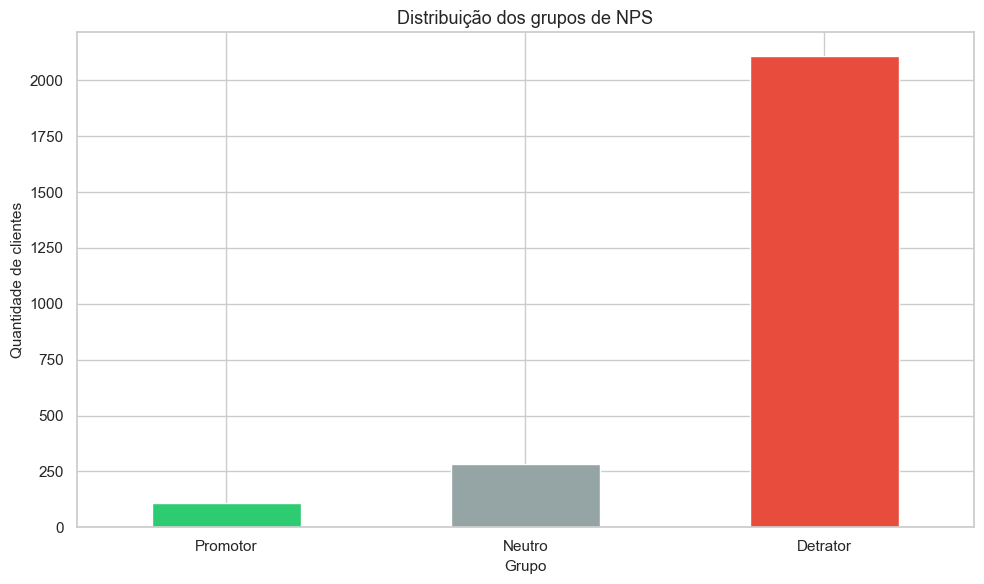

In [5]:
def classificar_nps(nota_nps):
    if nota_nps >= 9:
        return "Promotor"
    if nota_nps >= 7:
        return "Neutro"
    return "Detrator"


dados_nps["grupo_nps"] = dados_nps["nps_score"].apply(classificar_nps)

distribuicao_grupos = dados_nps["grupo_nps"].value_counts().reindex(
    ["Promotor", "Neutro", "Detrator"]
)
distribuicao_percentual = (
    dados_nps["grupo_nps"].value_counts(normalize=True).reindex(
        ["Promotor", "Neutro", "Detrator"]
    )
    * 100
)

resumo_grupos = pd.DataFrame(
    {
        "quantidade": distribuicao_grupos,
        "percentual": distribuicao_percentual.round(1),
    }
)
display(resumo_grupos)

total_clientes = len(dados_nps)
total_promotores = (dados_nps["grupo_nps"] == "Promotor").sum()
total_detratores = (dados_nps["grupo_nps"] == "Detrator").sum()
nps_geral = ((total_promotores - total_detratores) / total_clientes) * 100

print(f"NPS geral calculado na base: {nps_geral:.1f}")

ax = distribuicao_grupos.plot(
    kind="bar",
    color=["#2ecc71", "#95a5a6", "#e74c3c"],
    title="Distribuição dos grupos de NPS",
)
ax.set_xlabel("Grupo")
ax.set_ylabel("Quantidade de clientes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


### Visão inicial por região

Validar se existe dispersão relevante do NPS entre as regiões atendidas.


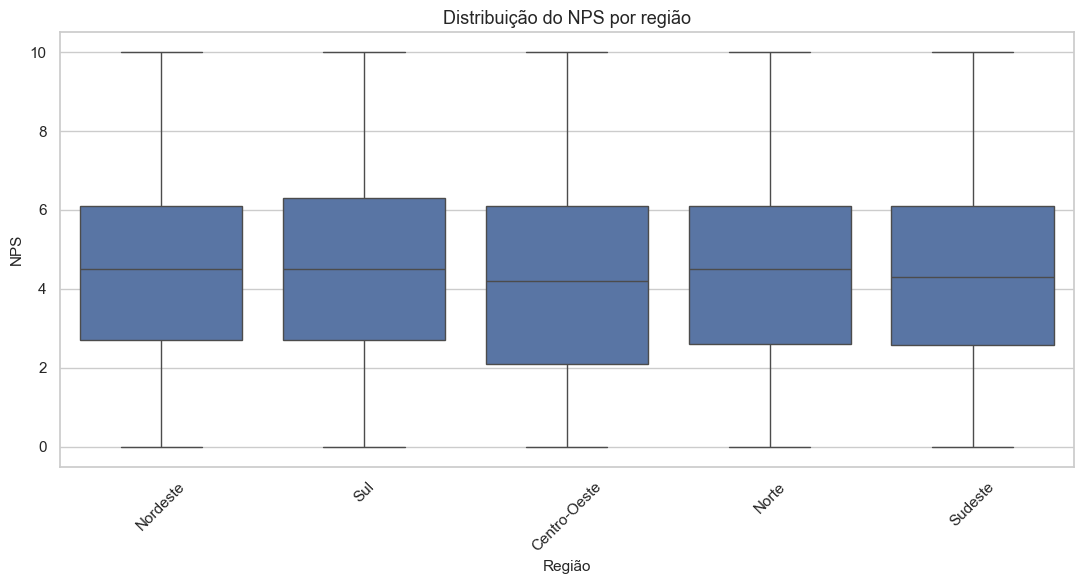

In [6]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=dados_nps, x="customer_region", y="nps_score")
plt.title("Distribuição do NPS por região")
plt.xlabel("Região")
plt.ylabel("NPS")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Correlação geral das variáveis numéricas

A matriz abaixo ajuda a identificar quais variáveis têm associação mais forte com o NPS e quais relações operacionais aparecem ao longo da jornada.


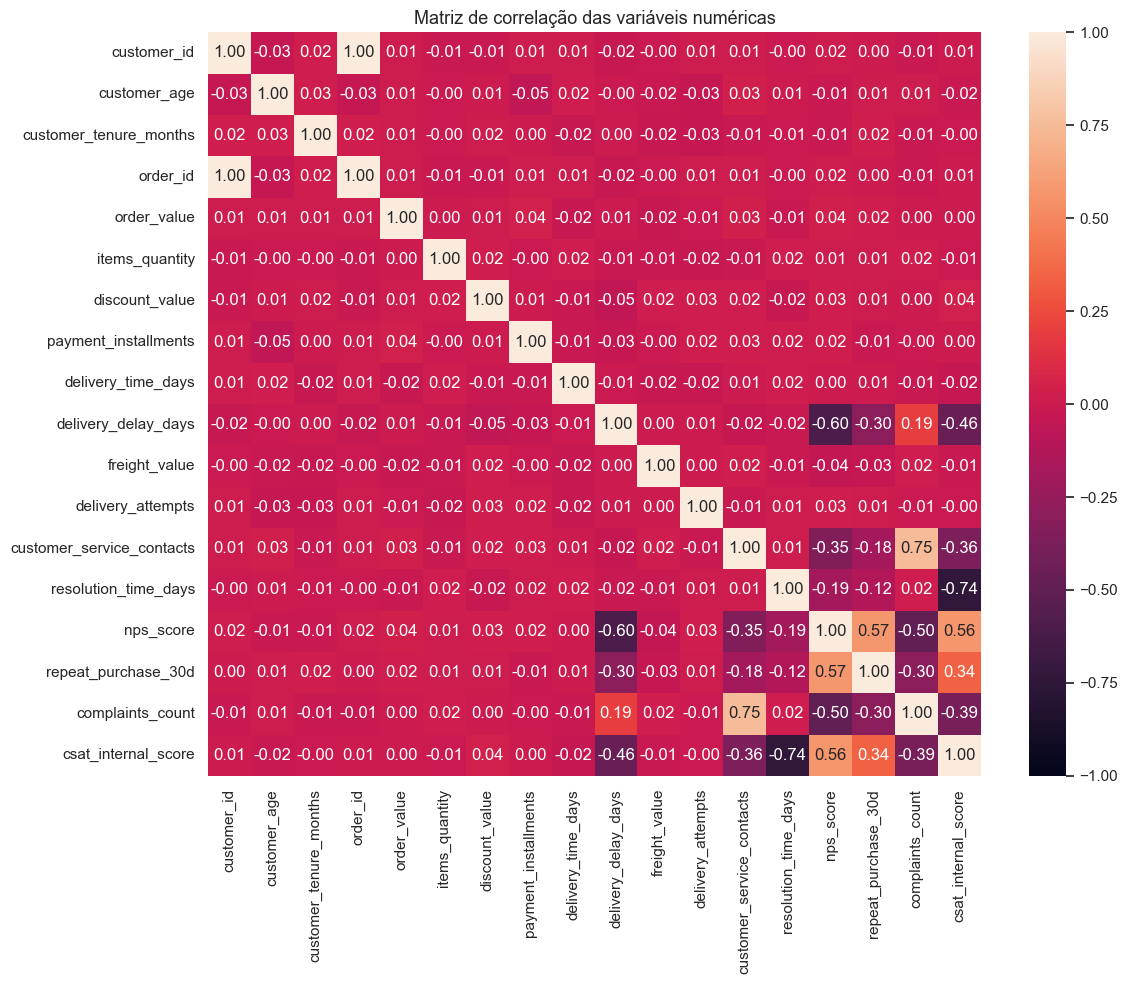

Variáveis com correlação absoluta acima de 0,10 com o NPS:
delivery_delay_days         -0.597
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
csat_internal_score          0.564
repeat_purchase_30d          0.570
Name: nps_score, dtype: float64


In [7]:
colunas_numericas = dados_nps.select_dtypes(exclude="object").columns
matriz_correlacao_geral = dados_nps[colunas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_correlacao_geral,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    vmin=-1,
    vmax=1,
)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

correlacoes_relevantes_nps = (
    matriz_correlacao_geral["nps_score"]
    .drop("nps_score")
    .loc[lambda serie: serie.abs() > 0.10]
    .sort_values()
)

print("Variáveis com correlação absoluta acima de 0,10 com o NPS:")
print(correlacoes_relevantes_nps.round(3))


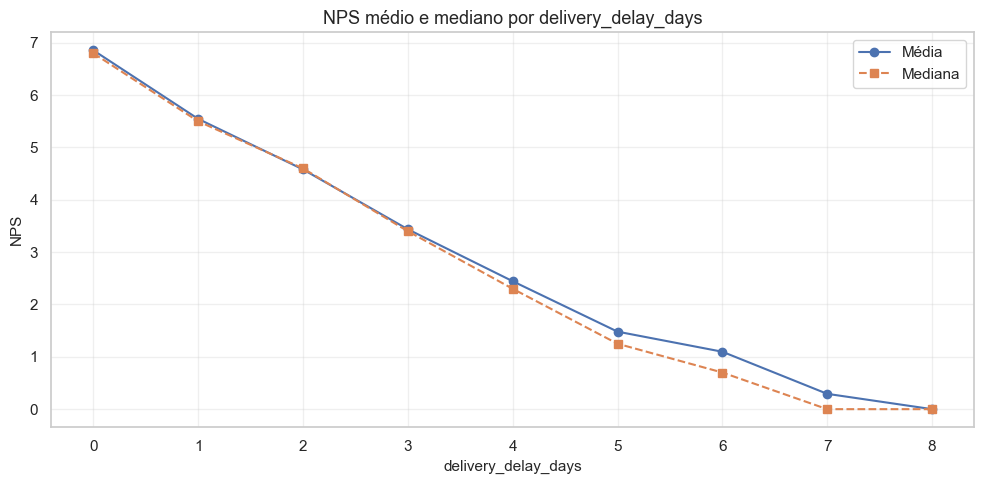

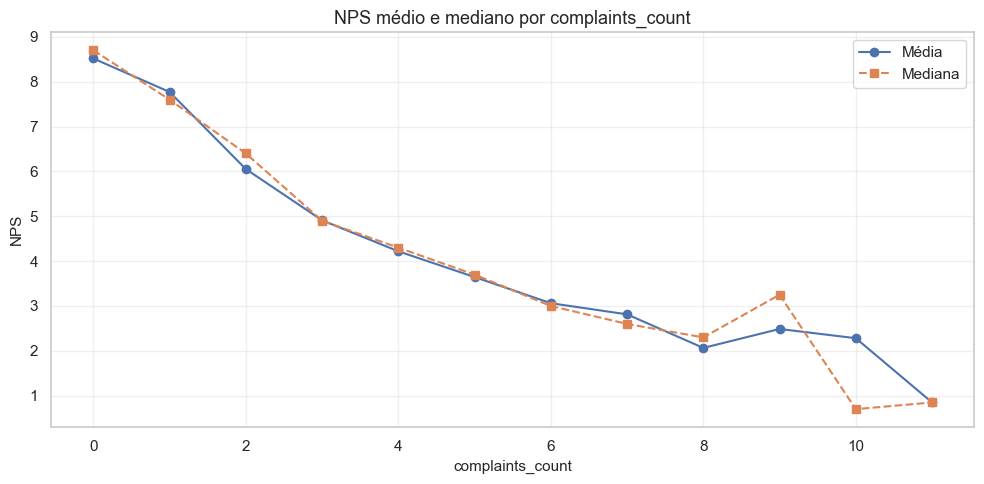

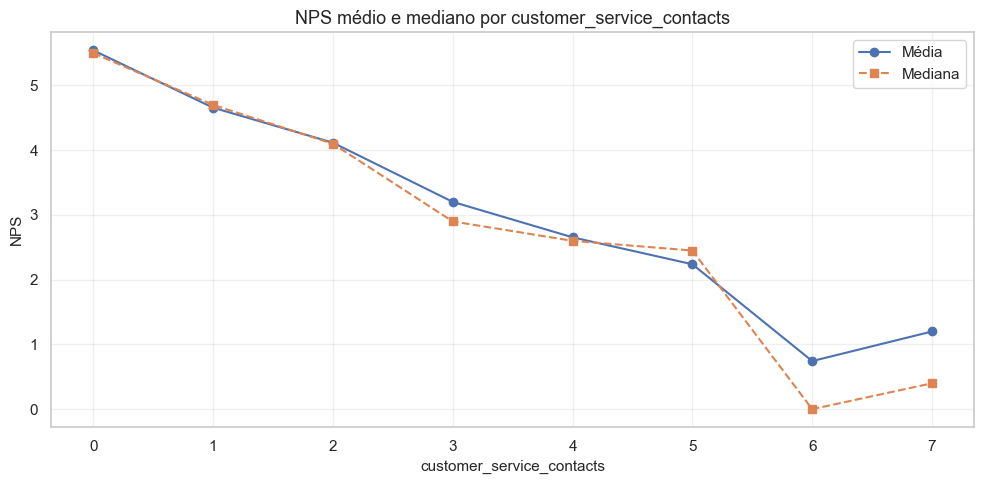

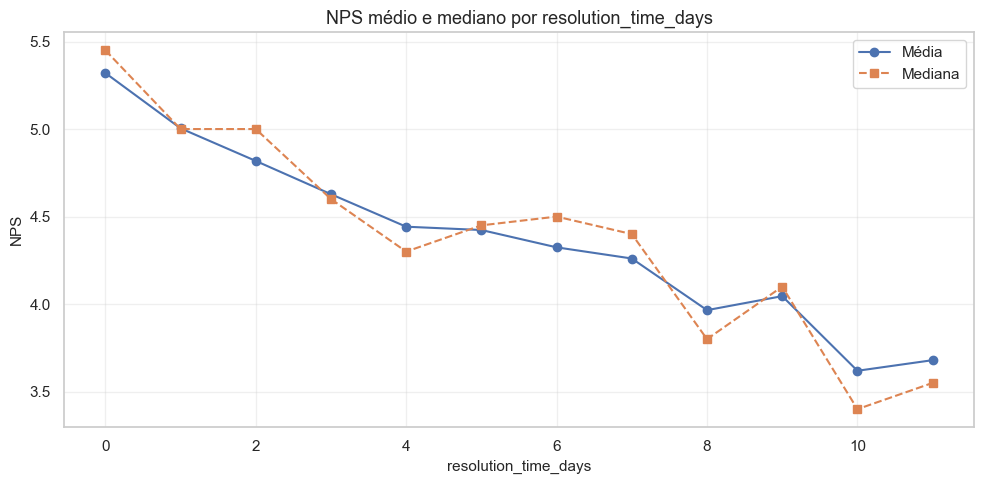

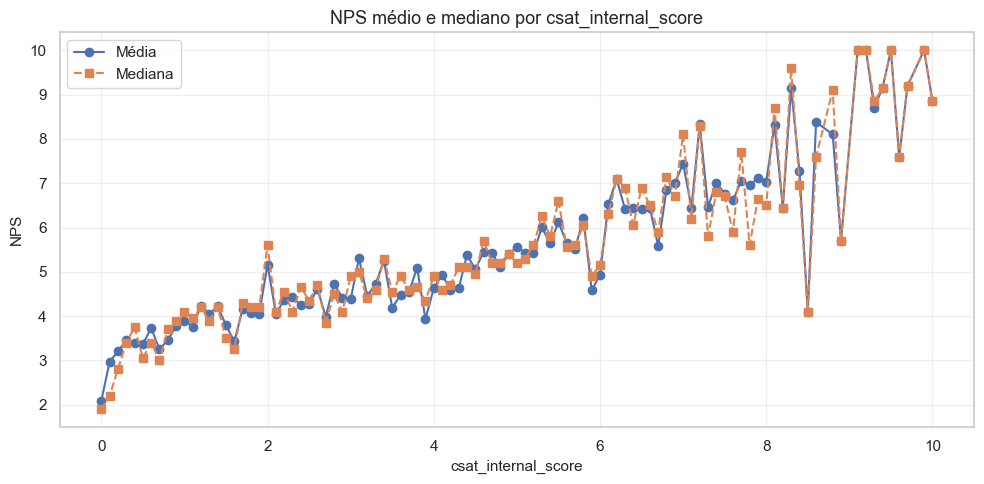

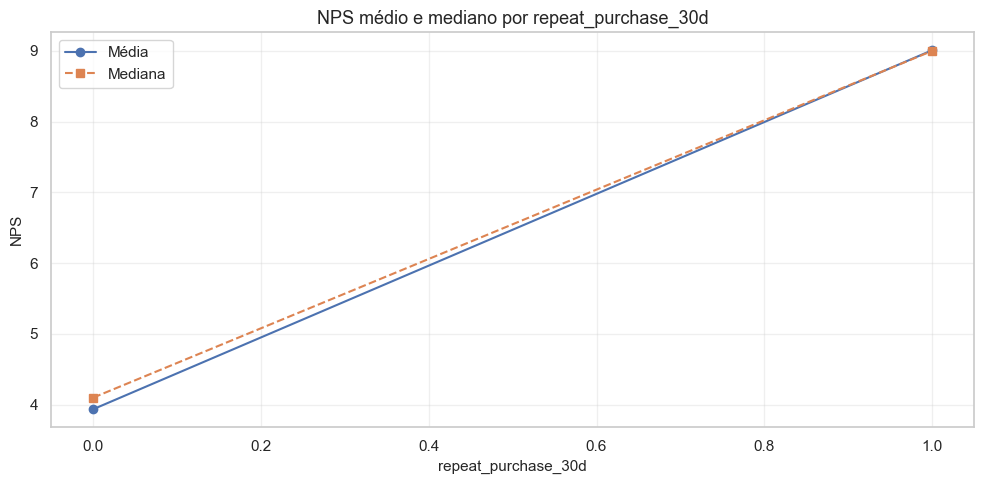

In [8]:
for coluna in correlacoes_relevantes_nps.index:
    resumo_variavel = (
        dados_nps.groupby(coluna)["nps_score"]
        .agg(["mean", "median"])
        .reset_index()
        .sort_values(coluna)
    )

    fig, eixo = plt.subplots(figsize=(10, 5))
    eixo.plot(resumo_variavel[coluna], resumo_variavel["mean"], marker="o", label="Média")
    eixo.plot(
        resumo_variavel[coluna],
        resumo_variavel["median"],
        marker="s",
        linestyle="--",
        label="Mediana",
    )
    eixo.set_title(f"NPS médio e mediano por {coluna}")
    eixo.set_xlabel(coluna)
    eixo.set_ylabel("NPS")
    eixo.grid(alpha=0.3)
    eixo.legend()
    plt.tight_layout()
    plt.show()


### Variáveis associadas à fricção da jornada

Três sinais recorrentes de insatisfação: atraso na entrega, quantidade de reclamações e volume de contatos com atendimento.


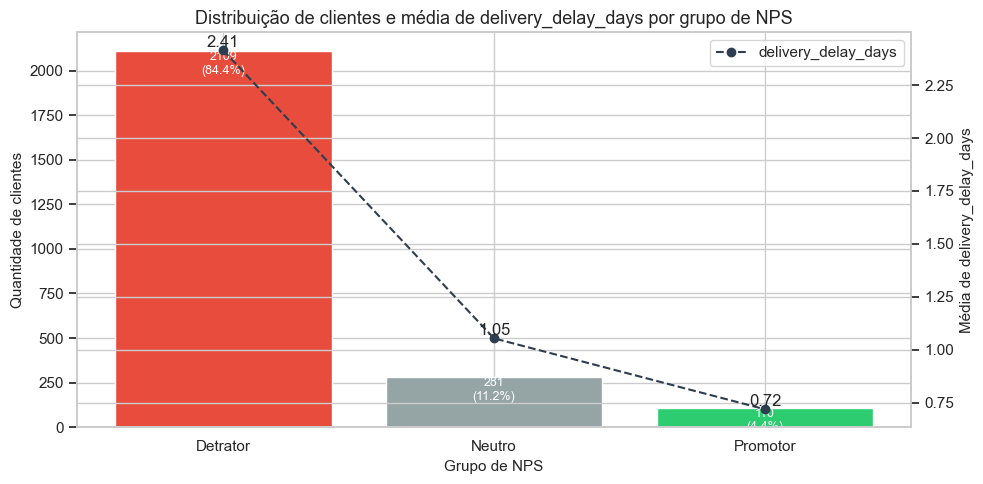

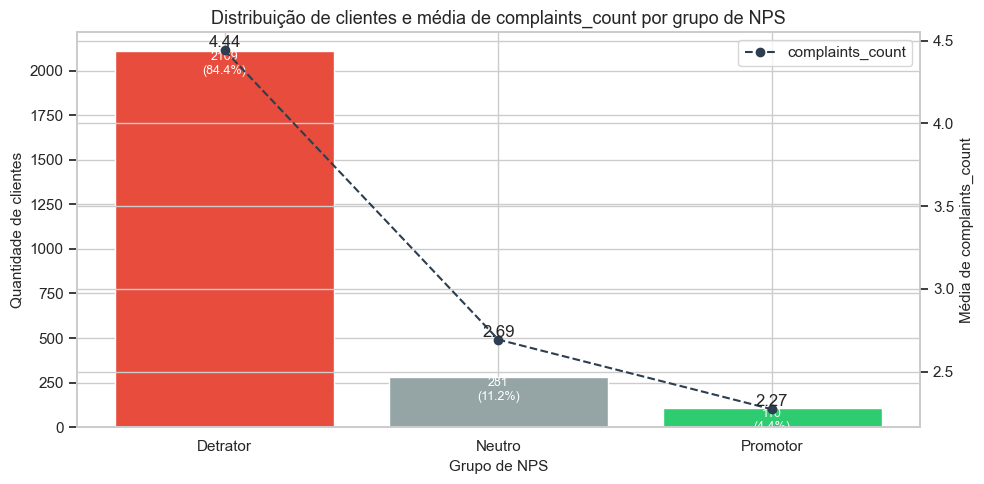

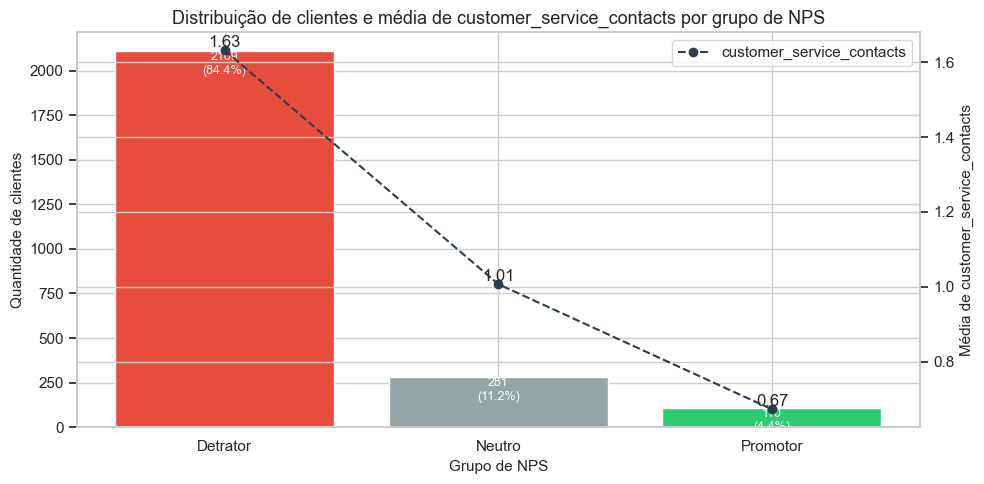

In [9]:
variaveis_friccao = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
]

ordem_grupos = ["Detrator", "Neutro", "Promotor"]

for variavel in variaveis_friccao:
    resumo_grupo = (
        dados_nps.groupby("grupo_nps", as_index=False)
        .agg(
            quantidade_clientes=("grupo_nps", "size"),
            media_variavel=(variavel, "mean"),
        )
    )

    resumo_grupo["grupo_nps"] = pd.Categorical(
        resumo_grupo["grupo_nps"],
        categories=ordem_grupos,
        ordered=True,
    )
    resumo_grupo = resumo_grupo.sort_values("grupo_nps")
    resumo_grupo["percentual_clientes"] = (
        resumo_grupo["quantidade_clientes"] / resumo_grupo["quantidade_clientes"].sum()
    )

    fig, eixo_barras = plt.subplots(figsize=(10, 5))
    barras = eixo_barras.bar(
        resumo_grupo["grupo_nps"],
        resumo_grupo["quantidade_clientes"],
        color=["#e74c3c", "#95a5a6", "#2ecc71"],
    )
    eixo_barras.set_title(f"Distribuição de clientes e média de {variavel} por grupo de NPS")
    eixo_barras.set_xlabel("Grupo de NPS")
    eixo_barras.set_ylabel("Quantidade de clientes")

    for barra, quantidade, percentual in zip(
        barras,
        resumo_grupo["quantidade_clientes"],
        resumo_grupo["percentual_clientes"],
    ):
        eixo_barras.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
            f"{quantidade}\n({percentual:.1%})",
            ha="center",
            va="top",
            color="white",
            fontsize=9,
        )

    eixo_linha = eixo_barras.twinx()
    eixo_linha.plot(
        resumo_grupo["grupo_nps"],
        resumo_grupo["media_variavel"],
        marker="o",
        color="#2c3e50",
        linestyle="--",
        label=variavel,
    )
    eixo_linha.set_ylabel(f"Média de {variavel}")

    for grupo, valor in zip(resumo_grupo["grupo_nps"], resumo_grupo["media_variavel"]):
        eixo_linha.text(grupo, valor, f"{valor:.2f}", ha="center", va="bottom")

    eixo_linha.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


### Recorte específico dos detratores

Como a base concentra muitos clientes insatisfeitos, faz sentido isolar esse grupo para entender quais variáveis mais acompanham a piora do NPS dentro do próprio conjunto de detratores.


In [10]:
dados_detratores = dados_nps.loc[dados_nps["grupo_nps"] == "Detrator"].copy()
dados_promotores = dados_nps.loc[dados_nps["grupo_nps"] == "Promotor"].copy()

print(f"Total de detratores: {len(dados_detratores)}")
print(f"Total de promotores: {len(dados_promotores)}")

metricas_operacionais = [
    "customer_age",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "repeat_purchase_30d",
    "complaints_count",
    "csat_internal_score",
]


Total de detratores: 2109
Total de promotores: 110


Correlação com o NPS dentro do grupo de detratores:
delivery_delay_days         -0.525
complaints_count            -0.373
customer_service_contacts   -0.298
resolution_time_days        -0.139
freight_value               -0.040
customer_age                -0.015
customer_tenure_months      -0.013
delivery_time_days          -0.011
discount_value               0.011
order_value                  0.017
delivery_attempts            0.017
payment_installments         0.020
items_quantity               0.026
csat_internal_score          0.464
repeat_purchase_30d            NaN
Name: nps_score, dtype: float64


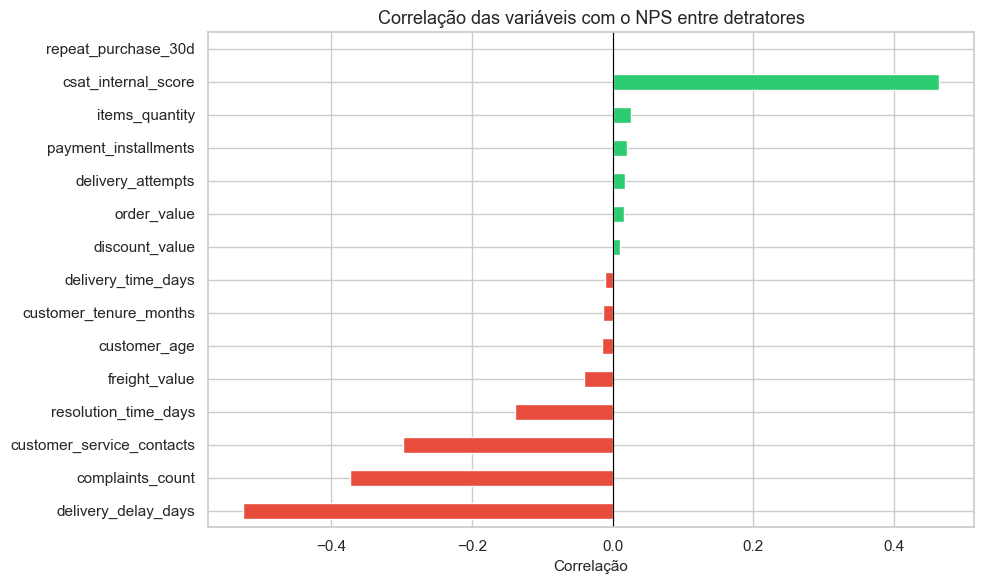

In [11]:
correlacao_detratores = (
    dados_detratores[metricas_operacionais + ["nps_score"]]
    .corr()["nps_score"]
    .drop("nps_score")
    .sort_values()
)

print("Correlação com o NPS dentro do grupo de detratores:")
print(correlacao_detratores.round(3))

plt.figure(figsize=(10, 6))
correlacao_detratores.plot(
    kind="barh",
    color=["#e74c3c" if valor < 0 else "#2ecc71" for valor in correlacao_detratores],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação das variáveis com o NPS entre detratores")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


Correlação com o NPS dentro do grupo de promotores:
delivery_delay_days         -0.194
delivery_attempts           -0.156
complaints_count            -0.148
order_value                 -0.109
customer_age                -0.104
customer_service_contacts   -0.091
customer_tenure_months      -0.054
items_quantity              -0.051
payment_installments         0.005
freight_value                0.006
delivery_time_days           0.015
resolution_time_days         0.026
discount_value               0.106
csat_internal_score          0.133
repeat_purchase_30d            NaN
Name: nps_score, dtype: float64


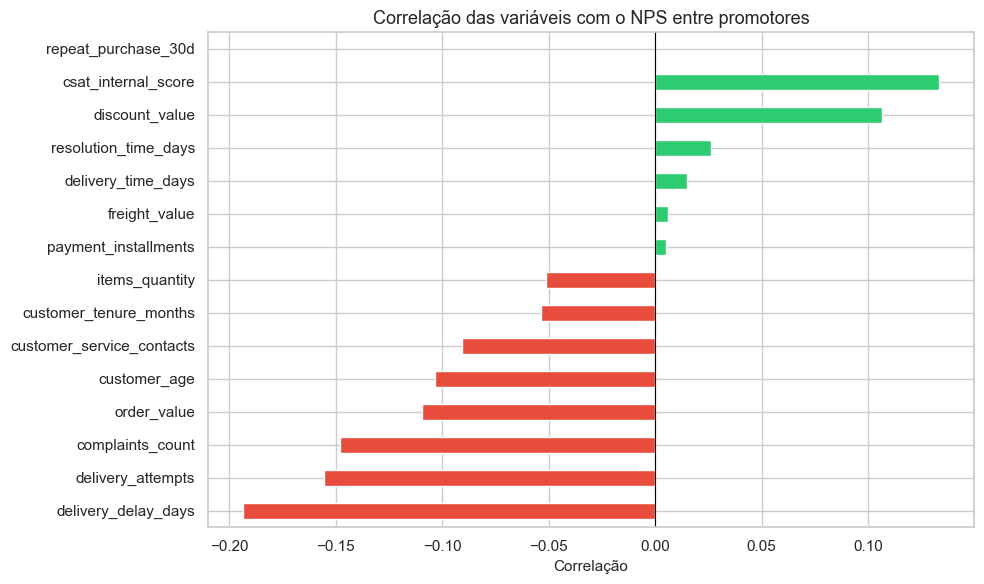

In [12]:
correlacao_promotores = (
    dados_promotores[metricas_operacionais + ["nps_score"]]
    .corr()["nps_score"]
    .drop("nps_score")
    .sort_values()
)

print("Correlação com o NPS dentro do grupo de promotores:")
print(correlacao_promotores.round(3))

plt.figure(figsize=(10, 6))
correlacao_promotores.plot(
    kind="barh",
    color=["#e74c3c" if valor < 0 else "#2ecc71" for valor in correlacao_promotores],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação das variáveis com o NPS entre promotores")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


,media_detratores,media_promotores,diferenca,impacto_percentual
complaints_count,4.44,2.27,2.17,95.6
resolution_time_days,5.69,3.70,1.99,53.8
delivery_delay_days,2.41,0.72,1.69,234.7
freight_value,38.30,37.05,1.25,3.4
customer_service_contacts,1.63,0.67,0.96,143.3
delivery_time_days,7.99,7.94,0.05,0.6
customer_age,43.40,43.63,-0.23,-0.5
customer_tenure_months,61.43,63.00,-1.57,-2.5


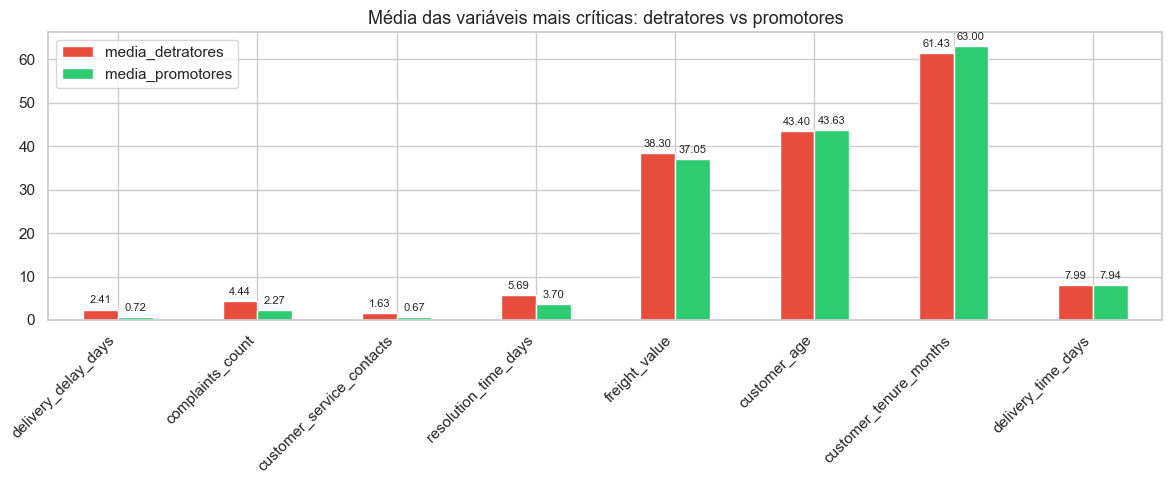

In [13]:
variaveis_negativas_detratores = correlacao_detratores[correlacao_detratores < 0].index.tolist()

medias_detratores = dados_detratores[variaveis_negativas_detratores].mean()
medias_promotores = dados_promotores[variaveis_negativas_detratores].mean()

comparacao_grupos = pd.DataFrame(
    {
        "media_detratores": medias_detratores,
        "media_promotores": medias_promotores,
    }
).round(2)

comparacao_grupos["diferenca"] = (
    comparacao_grupos["media_detratores"] - comparacao_grupos["media_promotores"]
).round(2)
comparacao_grupos["impacto_percentual"] = (
    comparacao_grupos["diferenca"] / comparacao_grupos["media_promotores"] * 100
).round(1)

display(comparacao_grupos.sort_values("diferenca", ascending=False))

eixo = comparacao_grupos[["media_detratores", "media_promotores"]].plot(
    kind="bar",
    figsize=(12, 5),
    color=["#e74c3c", "#2ecc71"],
    title="Média das variáveis mais críticas: detratores vs promotores",
)

for container in eixo.containers:
    eixo.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Recortes regionais

Combinação entre tempo de entrega e região para entender diferenças na experiência.


,media_entrega,media_nps,total_clientes
customer_region,,,
Sudeste,8.20,4.37,520
Nordeste,8.16,4.42,485
Sul,8.07,4.49,521
Centro-Oeste,7.91,4.21,468
Norte,7.76,4.38,506


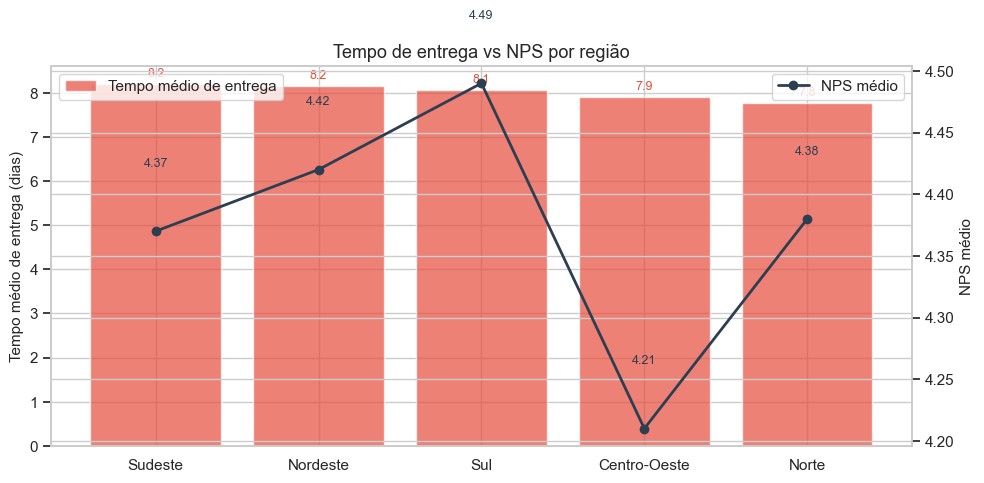

In [14]:
analise_regional = (
    dados_nps.groupby("customer_region")
    .agg(
        media_entrega=("delivery_time_days", "mean"),
        media_nps=("nps_score", "mean"),
        total_clientes=("customer_id", "count"),
    )
    .round(2)
    .sort_values("media_entrega", ascending=False)
)

display(analise_regional)

fig, eixo_barras = plt.subplots(figsize=(10, 5))
eixo_linha = eixo_barras.twinx()

barras = eixo_barras.bar(
    analise_regional.index,
    analise_regional["media_entrega"],
    color="#e74c3c",
    alpha=0.7,
    label="Tempo médio de entrega",
)
eixo_linha.plot(
    analise_regional.index,
    analise_regional["media_nps"],
    color="#2c3e50",
    marker="o",
    linewidth=2,
    label="NPS médio",
)

for barra in barras:
    eixo_barras.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{barra.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e74c3c",
    )

for posicao, (_, linha) in enumerate(analise_regional.iterrows()):
    eixo_linha.text(
        posicao,
        linha["media_nps"] + 0.05,
        f"{linha['media_nps']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2c3e50",
    )

eixo_barras.set_title("Tempo de entrega vs NPS por região")
eixo_barras.set_ylabel("Tempo médio de entrega (dias)")
eixo_linha.set_ylabel("NPS médio")
eixo_barras.tick_params(axis="x", rotation=0)
eixo_barras.legend(loc="upper left")
eixo_linha.legend(loc="upper right")
plt.tight_layout()
plt.show()


,media_entrega,media_nps,total_clientes
customer_region,,,
Sudeste,8.13,3.62,435
Nordeste,8.06,3.77,415
Centro-Oeste,8.00,3.43,394
Sul,7.98,3.71,434
Norte,7.80,3.72,431


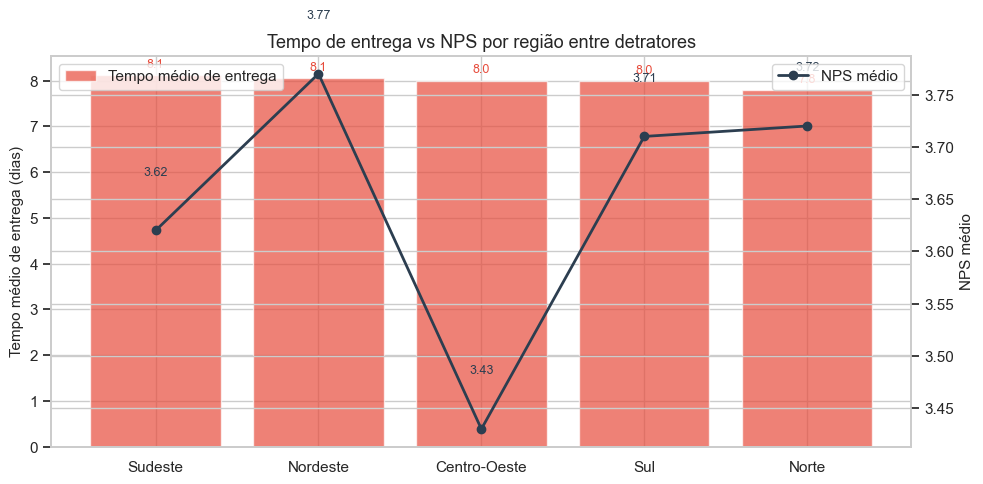

In [15]:
analise_regional_detratores = (
    dados_detratores.groupby("customer_region")
    .agg(
        media_entrega=("delivery_time_days", "mean"),
        media_nps=("nps_score", "mean"),
        total_clientes=("customer_id", "count"),
    )
    .round(2)
    .sort_values("media_entrega", ascending=False)
)

display(analise_regional_detratores)

fig, eixo_barras = plt.subplots(figsize=(10, 5))
eixo_linha = eixo_barras.twinx()

barras = eixo_barras.bar(
    analise_regional_detratores.index,
    analise_regional_detratores["media_entrega"],
    color="#e74c3c",
    alpha=0.7,
    label="Tempo médio de entrega",
)
eixo_linha.plot(
    analise_regional_detratores.index,
    analise_regional_detratores["media_nps"],
    color="#2c3e50",
    marker="o",
    linewidth=2,
    label="NPS médio",
)

for barra in barras:
    eixo_barras.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{barra.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e74c3c",
    )

for posicao, (_, linha) in enumerate(analise_regional_detratores.iterrows()):
    eixo_linha.text(
        posicao,
        linha["media_nps"] + 0.05,
        f"{linha['media_nps']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2c3e50",
    )

eixo_barras.set_title("Tempo de entrega vs NPS por região entre detratores")
eixo_barras.set_ylabel("Tempo médio de entrega (dias)")
eixo_linha.set_ylabel("NPS médio")
eixo_barras.tick_params(axis="x", rotation=0)
eixo_barras.legend(loc="upper left")
eixo_linha.legend(loc="upper right")
plt.tight_layout()
plt.show()


,media_entrega,media_nps,total_clientes
customer_region,,,
Sudeste,9.35,9.55,23
Sul,8.87,9.72,23
Nordeste,8.67,9.54,21
Centro-Oeste,6.60,9.57,25
Norte,5.94,9.66,18


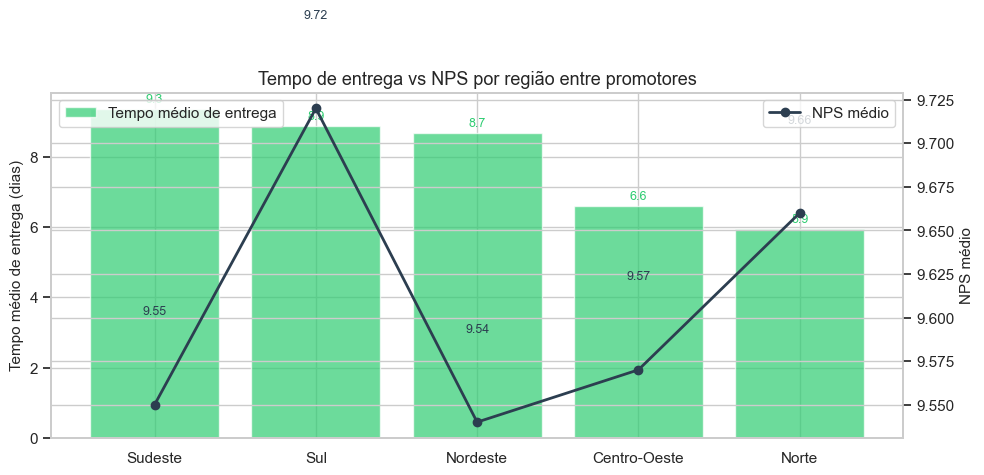

In [16]:
analise_regional_promotores = (
    dados_promotores.groupby("customer_region")
    .agg(
        media_entrega=("delivery_time_days", "mean"),
        media_nps=("nps_score", "mean"),
        total_clientes=("customer_id", "count"),
    )
    .round(2)
    .sort_values("media_entrega", ascending=False)
)

display(analise_regional_promotores)

fig, eixo_barras = plt.subplots(figsize=(10, 5))
eixo_linha = eixo_barras.twinx()

barras = eixo_barras.bar(
    analise_regional_promotores.index,
    analise_regional_promotores["media_entrega"],
    color="#2ecc71",
    alpha=0.7,
    label="Tempo médio de entrega",
)
eixo_linha.plot(
    analise_regional_promotores.index,
    analise_regional_promotores["media_nps"],
    color="#2c3e50",
    marker="o",
    linewidth=2,
    label="NPS médio",
)

for barra in barras:
    eixo_barras.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{barra.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2ecc71",
    )

for posicao, (_, linha) in enumerate(analise_regional_promotores.iterrows()):
    eixo_linha.text(
        posicao,
        linha["media_nps"] + 0.05,
        f"{linha['media_nps']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2c3e50",
    )

eixo_barras.set_title("Tempo de entrega vs NPS por região entre promotores")
eixo_barras.set_ylabel("Tempo médio de entrega (dias)")
eixo_linha.set_ylabel("NPS médio")
eixo_barras.tick_params(axis="x", rotation=0)
eixo_barras.legend(loc="upper left")
eixo_linha.legend(loc="upper right")
plt.tight_layout()
plt.show()


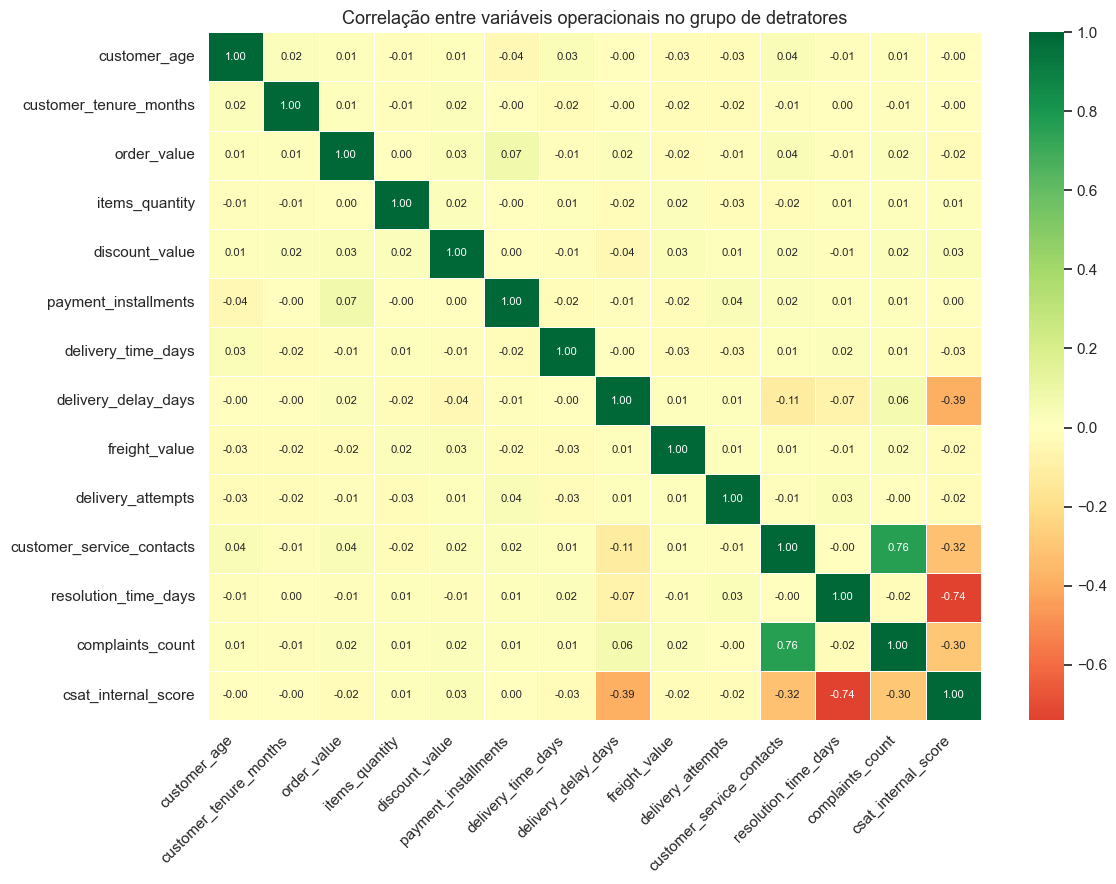

In [17]:
variaveis_operacionais_sem_nps = [
    "customer_age",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
]

matriz_correlacao_detratores = (
    dados_detratores[variaveis_operacionais_sem_nps].corr().round(2)
)

plt.figure(figsize=(12, 9))
sns.heatmap(
    matriz_correlacao_detratores,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title("Correlação entre variáveis operacionais no grupo de detratores")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Atraso de entrega como ponto de ruptura


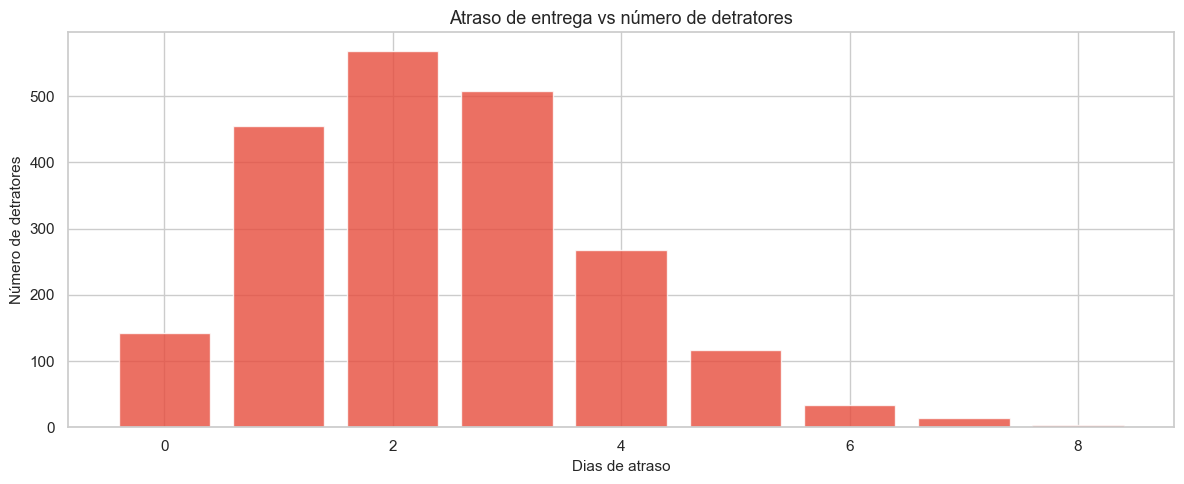

In [18]:
atraso_por_detratores = (
    dados_detratores.groupby("delivery_delay_days")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"delivery_delay_days": "atraso_dias", "customer_id": "numero_detratores"})
)

plt.figure(figsize=(12, 5))
plt.bar(
    atraso_por_detratores["atraso_dias"],
    atraso_por_detratores["numero_detratores"],
    color="#e74c3c",
    alpha=0.8,
)
plt.title("Atraso de entrega vs número de detratores")
plt.xlabel("Dias de atraso")
plt.ylabel("Número de detratores")
plt.tight_layout()
plt.show()


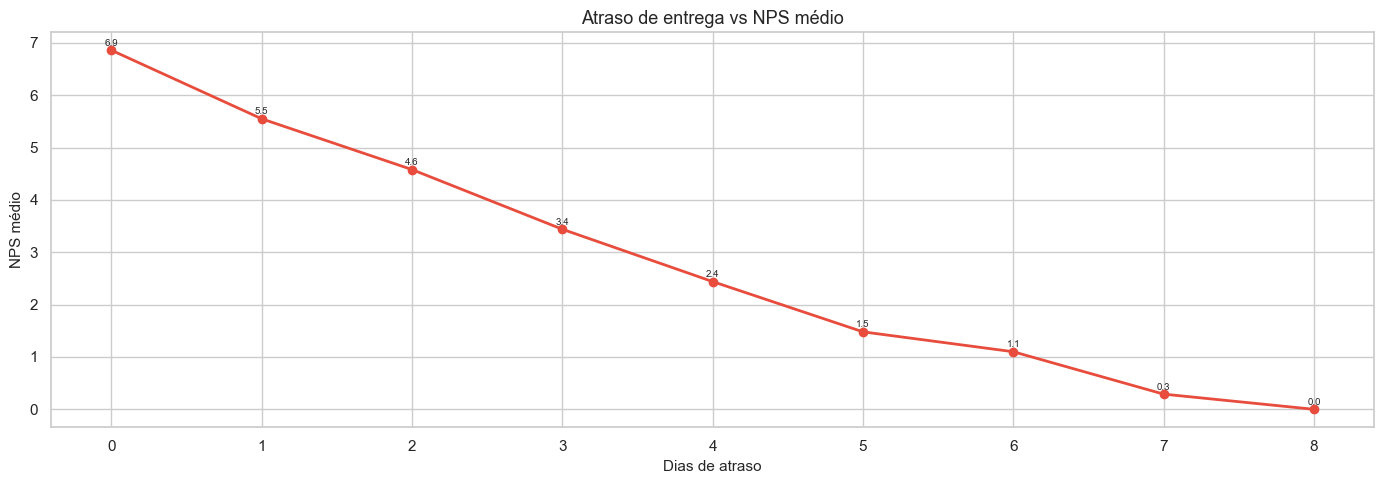

In [19]:
nps_medio_por_atraso = (
    dados_nps.groupby("delivery_delay_days")["nps_score"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"delivery_delay_days": "atraso_dias", "nps_score": "media_nps"})
    .sort_values("atraso_dias")
)

plt.figure(figsize=(14, 5))
plt.plot(
    nps_medio_por_atraso["atraso_dias"],
    nps_medio_por_atraso["media_nps"],
    color="#e74c3c",
    marker="o",
    linewidth=2,
)

for _, linha in nps_medio_por_atraso.iterrows():
    plt.text(
        linha["atraso_dias"],
        linha["media_nps"] + 0.05,
        f"{linha['media_nps']:.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

plt.title("Atraso de entrega vs NPS médio")
plt.xlabel("Dias de atraso")
plt.ylabel("NPS médio")
plt.xticks(nps_medio_por_atraso["atraso_dias"])
plt.tight_layout()
plt.show()


Tabela de variação do NPS por dia de atraso:


,atraso_dias,media_nps,variacao_nps
0,0,6.86,NaN
1,1,5.55,-1.31
2,2,4.58,-0.97
3,3,3.44,-1.14
4,4,2.44,-1.00
5,5,1.48,-0.96
6,6,1.10,-0.38
7,7,0.29,-0.81
8,8,0.00,-0.29


Ponto de maior queda observado: atraso de 1 dia(s), com variação de -1.31 ponto(s) no NPS.


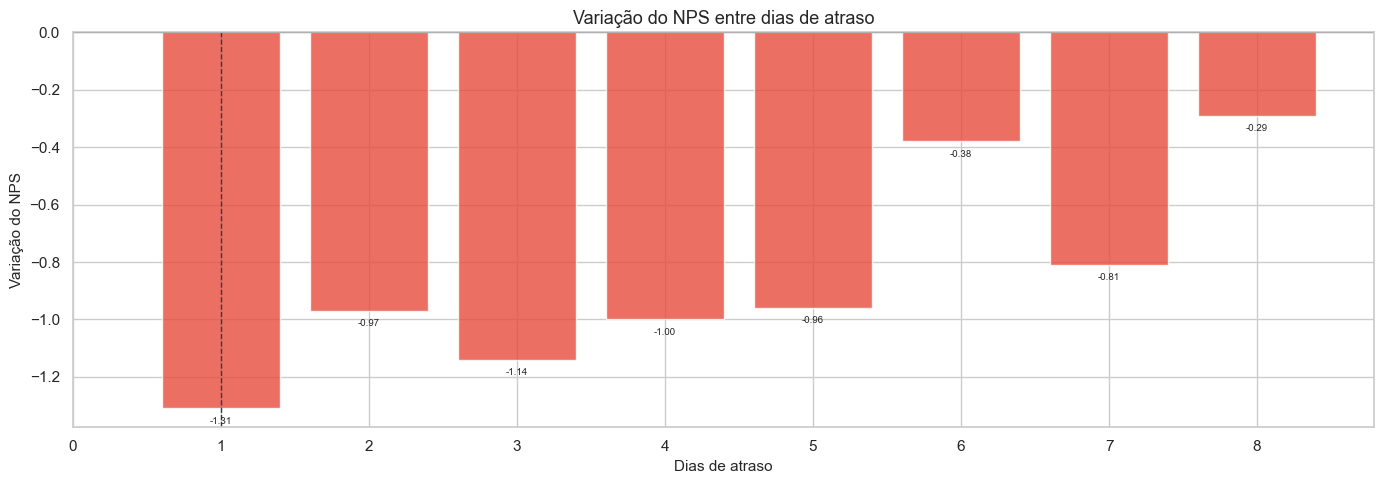

In [20]:
nps_medio_por_atraso["variacao_nps"] = nps_medio_por_atraso["media_nps"].diff().round(2)
ponto_ruptura = nps_medio_por_atraso.loc[
    nps_medio_por_atraso["variacao_nps"].idxmin()
]

print("Tabela de variação do NPS por dia de atraso:")
display(nps_medio_por_atraso)
print(
    f"Ponto de maior queda observado: atraso de {int(ponto_ruptura['atraso_dias'])} dia(s), "
    f"com variação de {ponto_ruptura['variacao_nps']:.2f} ponto(s) no NPS."
)

plt.figure(figsize=(14, 5))
cores = [
    "#e74c3c" if pd.notna(valor) and valor < 0 else "#2ecc71"
    for valor in nps_medio_por_atraso["variacao_nps"]
]
barras = plt.bar(
    nps_medio_por_atraso["atraso_dias"],
    nps_medio_por_atraso["variacao_nps"],
    color=cores,
    alpha=0.8,
)

for barra, valor in zip(barras, nps_medio_por_atraso["variacao_nps"]):
    if pd.notna(valor):
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + (0.03 if valor >= 0 else -0.06),
            f"{valor:+.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(ponto_ruptura["atraso_dias"], color="#2c3e50", linestyle="--", linewidth=1)
plt.title("Variação do NPS entre dias de atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("Variação do NPS")
plt.xticks(nps_medio_por_atraso["atraso_dias"])
plt.tight_layout()
plt.show()


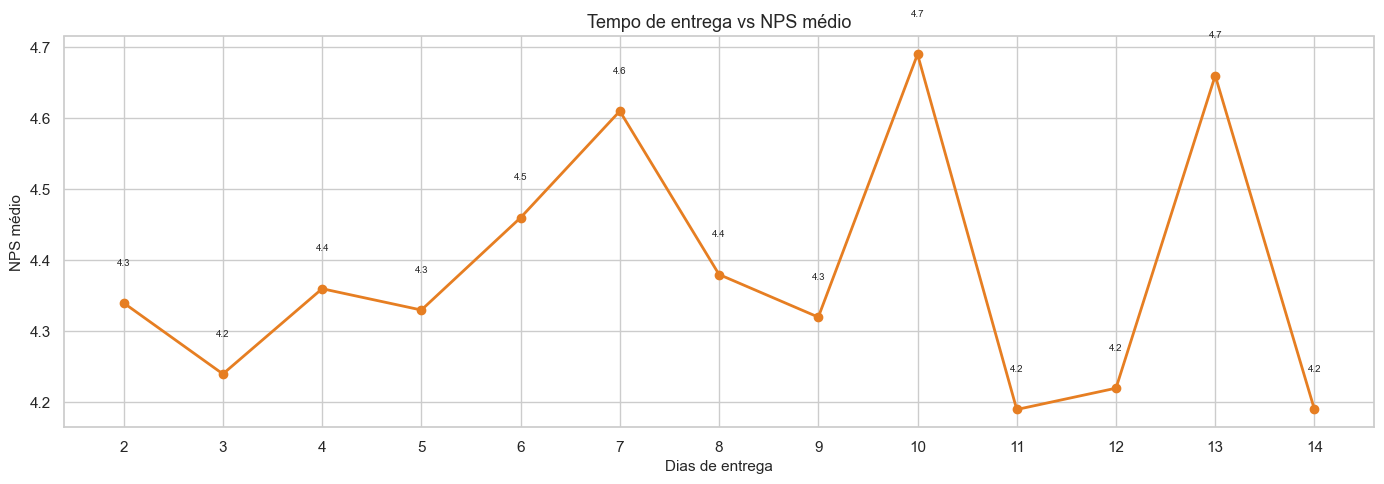

,entrega_dias,media_nps,variacao_nps
0,2,4.34,NaN
1,3,4.24,-0.10
2,4,4.36,0.12
3,5,4.33,-0.03
4,6,4.46,0.13
5,7,4.61,0.15
6,8,4.38,-0.23
7,9,4.32,-0.06
8,10,4.69,0.37
9,11,4.19,-0.50


In [21]:
nps_medio_por_entrega = (
    dados_nps.groupby("delivery_time_days")["nps_score"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"delivery_time_days": "entrega_dias", "nps_score": "media_nps"})
    .sort_values("entrega_dias")
)

plt.figure(figsize=(14, 5))
plt.plot(
    nps_medio_por_entrega["entrega_dias"],
    nps_medio_por_entrega["media_nps"],
    color="#e67e22",
    marker="o",
    linewidth=2,
)

for _, linha in nps_medio_por_entrega.iterrows():
    plt.text(
        linha["entrega_dias"],
        linha["media_nps"] + 0.05,
        f"{linha['media_nps']:.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

plt.title("Tempo de entrega vs NPS médio")
plt.xlabel("Dias de entrega")
plt.ylabel("NPS médio")
plt.xticks(nps_medio_por_entrega["entrega_dias"])
plt.tight_layout()
plt.show()

nps_medio_por_entrega["variacao_nps"] = nps_medio_por_entrega["media_nps"].diff().round(2)
display(nps_medio_por_entrega)


### Perfil de cliente e fricção acumulada

Jornada que combina atrito operacional e perfil de relacionamento do cliente


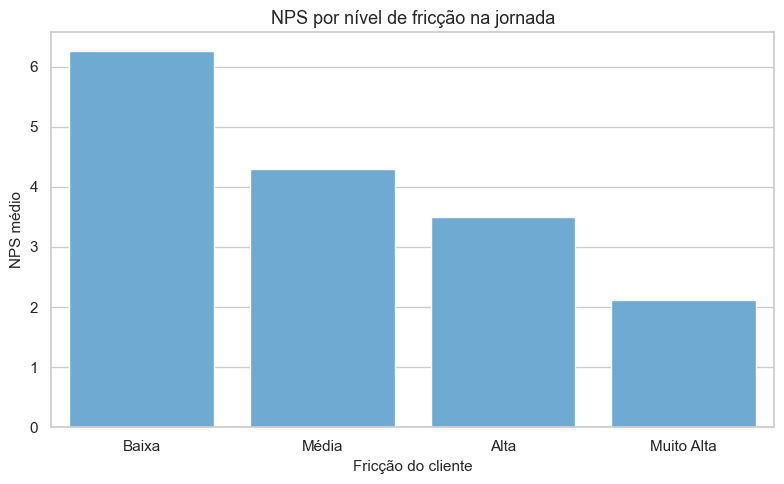

In [22]:
dados_nps["score_friccao"] = (
    dados_nps["delivery_delay_days"]
    + dados_nps["customer_service_contacts"]
    + dados_nps["complaints_count"]
)

dados_nps["faixa_friccao"] = pd.qcut(
    dados_nps["score_friccao"],
    4,
    labels=["Baixa", "Média", "Alta", "Muito Alta"],
)

nps_por_friccao = (
    dados_nps.groupby("faixa_friccao", observed=False)["nps_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=nps_por_friccao, x="faixa_friccao", y="nps_score", color="#5dade2")
plt.title("NPS por nível de fricção na jornada")
plt.xlabel("Fricção do cliente")
plt.ylabel("NPS médio")
plt.tight_layout()
plt.show()


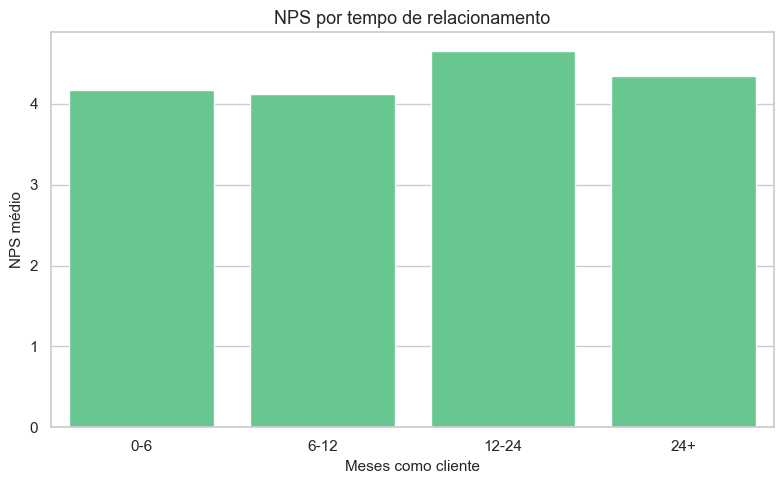

In [23]:
dados_nps["faixa_relacionamento"] = pd.cut(
    dados_nps["customer_tenure_months"],
    bins=[0, 6, 12, 24, 60],
    labels=["0-6", "6-12", "12-24", "24+"],
)

nps_por_relacionamento = (
    dados_nps.groupby("faixa_relacionamento", observed=False)["nps_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=nps_por_relacionamento, x="faixa_relacionamento", y="nps_score", color="#58d68d")
plt.title("NPS por tempo de relacionamento")
plt.xlabel("Meses como cliente")
plt.ylabel("NPS médio")
plt.tight_layout()
plt.show()


### Faixa etária e recortes complementares

grupo_nps,Detrator,Neutro,Promotor
faixa_etaria,,,
18-25,84.7,10.7,4.6
26-35,80.4,14.0,5.6
36-45,88.6,8.3,3.1
46-55,82.5,13.5,4.1
56-65,87.0,8.4,4.6
65+,79.5,15.7,4.9


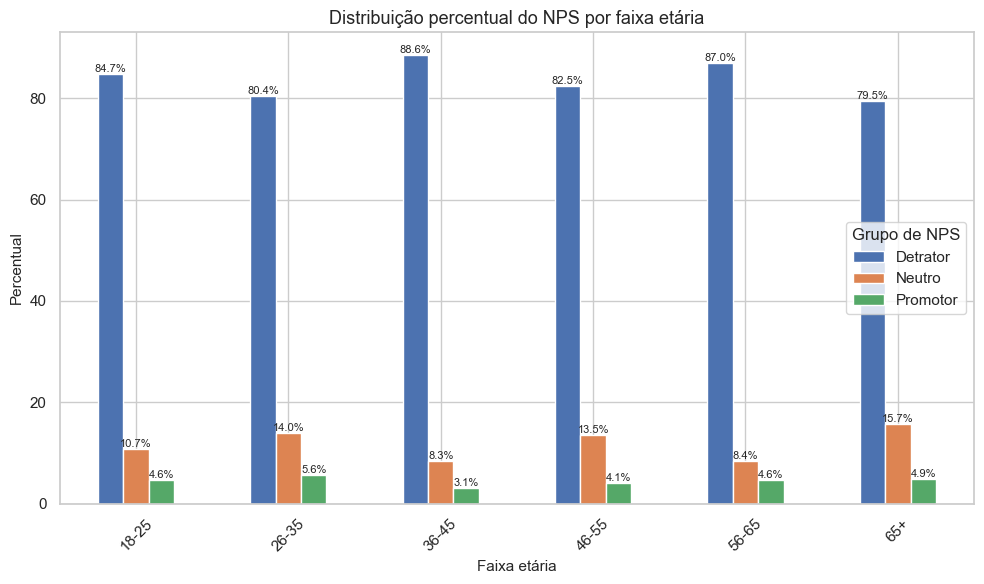

In [24]:
dados_idade = dados_nps.copy()
dados_idade["faixa_etaria"] = pd.cut(
    dados_idade["customer_age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"],
)

distribuicao_faixa_etaria = (
    dados_idade.groupby(["faixa_etaria", "grupo_nps"], observed=False)
    .size()
    .unstack(fill_value=0)
)
distribuicao_percentual_faixa_etaria = (
    distribuicao_faixa_etaria.div(distribuicao_faixa_etaria.sum(axis=1), axis=0) * 100
)

display(distribuicao_percentual_faixa_etaria.round(1))

eixo = distribuicao_percentual_faixa_etaria.plot(kind="bar", figsize=(10, 6))
plt.title("Distribuição percentual do NPS por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Percentual")
plt.xticks(rotation=45)
plt.legend(title="Grupo de NPS")
plt.tight_layout()

for barra in eixo.patches:
    altura = barra.get_height()
    if altura > 0:
        eixo.annotate(
            f"{altura:.1f}%",
            (barra.get_x() + barra.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.show()


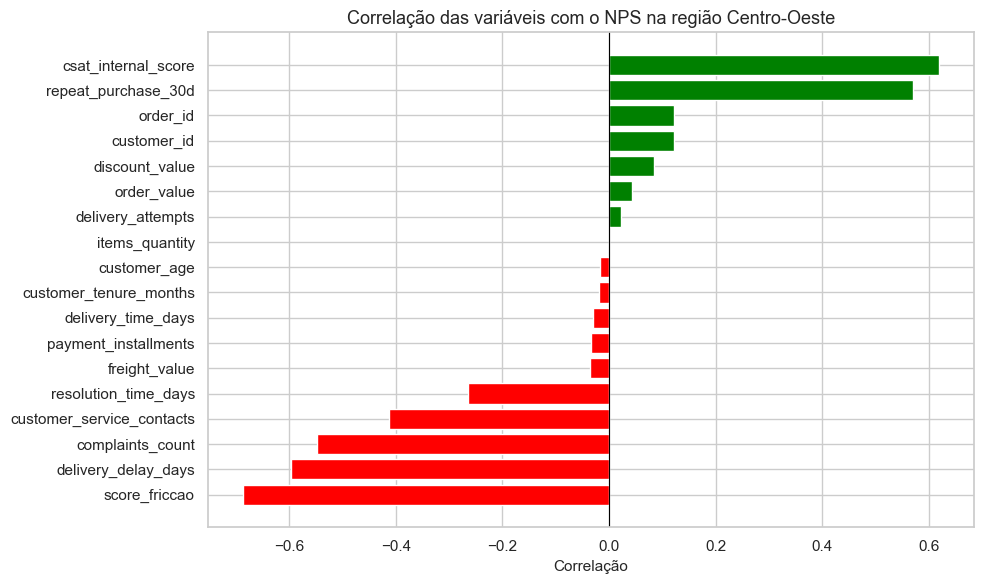

In [25]:
dados_centro_oeste = dados_idade.loc[dados_idade["customer_region"] == "Centro-Oeste"].copy()
correlacao_centro_oeste = (
    dados_centro_oeste.corr(numeric_only=True)["nps_score"].drop("nps_score").sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(
    correlacao_centro_oeste.index,
    correlacao_centro_oeste.values,
    color=["green" if valor > 0 else "red" for valor in correlacao_centro_oeste.values],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação das variáveis com o NPS na região Centro-Oeste")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


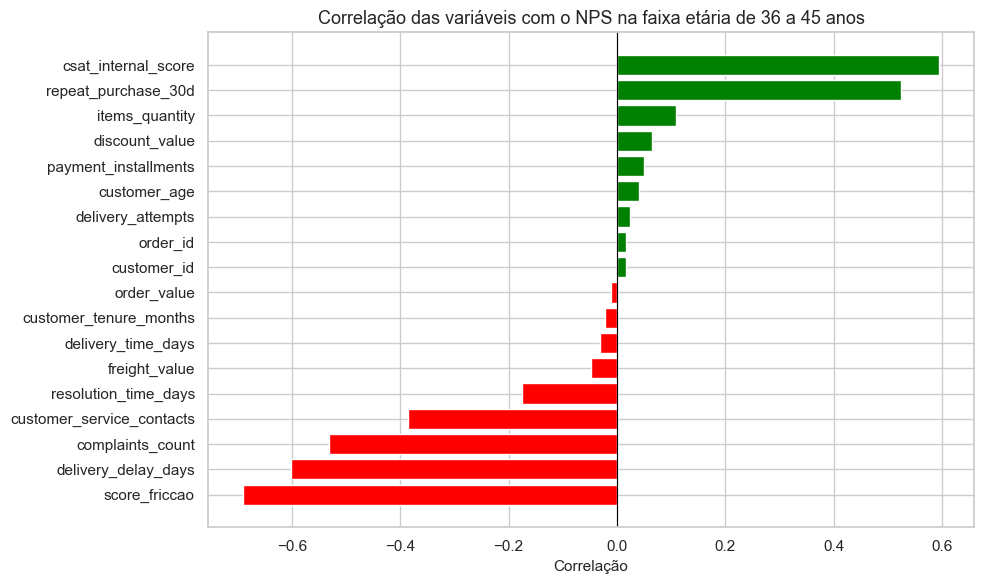

In [26]:
dados_faixa_36_45 = dados_idade.loc[dados_idade["faixa_etaria"] == "36-45"].copy()
correlacao_faixa_36_45 = (
    dados_faixa_36_45.corr(numeric_only=True)["nps_score"].drop("nps_score").sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(
    correlacao_faixa_36_45.index,
    correlacao_faixa_36_45.values,
    color=["green" if valor > 0 else "red" for valor in correlacao_faixa_36_45.values],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação das variáveis com o NPS na faixa etária de 36 a 45 anos")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


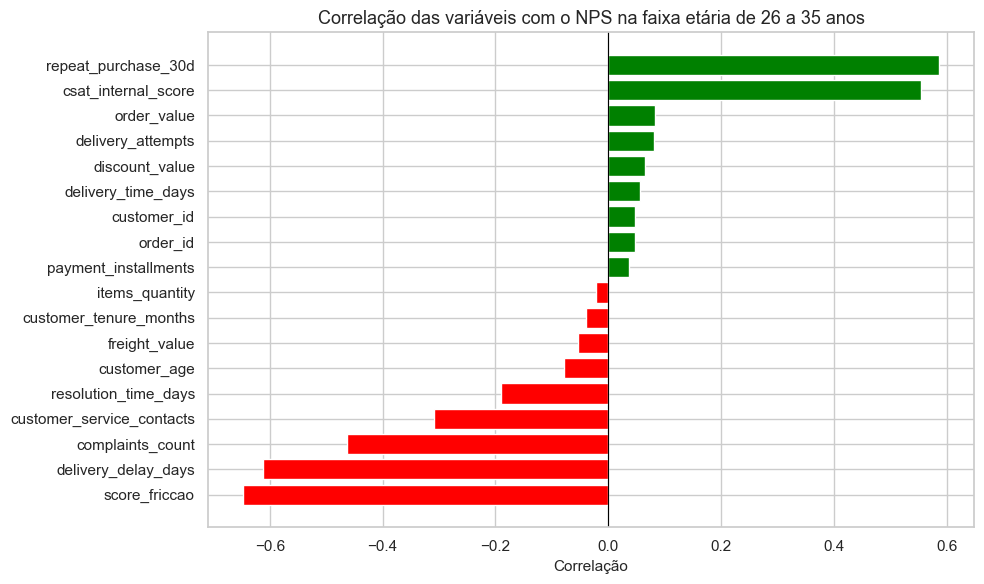

In [27]:
dados_faixa_26_35 = dados_idade.loc[dados_idade["faixa_etaria"] == "26-35"].copy()
correlacao_faixa_26_35 = (
    dados_faixa_26_35.corr(numeric_only=True)["nps_score"].drop("nps_score").sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(
    correlacao_faixa_26_35.index,
    correlacao_faixa_26_35.values,
    color=["green" if valor > 0 else "red" for valor in correlacao_faixa_26_35.values],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação das variáveis com o NPS na faixa etária de 26 a 35 anos")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


## 4. Principais insights da EDA

Principais Insights:

- **Atraso de entrega** aparece como o principal sinal de ruptura da experiência.
- **Reclamações e contatos com atendimento** aumentam conforme o NPS piora.
- **Diferenças regionais** ajudam a explicar parte da variação do NPS quando combinadas com tempo de entrega.
- **Fricção acumulada na jornada** tende a reduzir a satisfação média.

Em termos gerenciais, a leitura geral sugere priorizar redução de atrasos, prevenção de falhas logísticas e atuação mais rápida em jornadas com múltiplos sinais de fricção.
